<a href="https://colab.research.google.com/github/tamaraeliana908-art/LABORATORIO-11/blob/main/Copia_de_Actividad_practica_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="text-align: center; font-family: Arial, sans-serif;">

  <h1>Laboratorio practico #11</h1>
  
  <br><br>

  <h2>ELIANA TAMARA</h2>

  <br><br>

  <h3>INTELIGENCIA ARTIFICIAL – NIVEL BÁSICO</h3>

  <br><br>

  <h3>EQUIPO ACADÉMICO</h3>
  <p>
    Alejandra Lozano<br>
    Melany Mena<br>
    Gustavo Rodríguez
  </p>

  <br><br>

  <h3>CURSO IA NOCTURNA G-3745</h3>

  <br>

  <h3>MARZO – JUNIO 2026</h3>

</div>


1.Genera código en Python para Google Colab siguiendo buenas prácticas.

Importa: numpy, matplotlib.pyplot, seaborn, scipy.stats
Configura estilo visual profesional (seaborn)
Define explícitamente los datos:
horas_estudio = np.array([1,2,3,4,5,6,7,8,9,10])
puntaje_examen = np.array([50,55,65,70,75,78,85,90,92,94])
Valida que ambos arrays tengan la misma longitud
Imprime un resumen inicial de los datos
El código debe ser limpio, comentado y listo para ejecutar.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ============================================================
# CONFIGURACIÓN VISUAL PROFESIONAL
# ============================================================
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

# ============================================================
# DEFINICIÓN DE DATOS
# ============================================================
horas_estudio   = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
puntaje_examen  = np.array([50, 55, 65, 70, 75, 78, 85, 90, 92, 94])

# ============================================================
# VALIDACIÓN
# ============================================================
assert len(horas_estudio) == len(puntaje_examen), (
    f"Error: los arrays no tienen la misma longitud "
    f"({len(horas_estudio)} vs {len(puntaje_examen)})"
)
print("✅ Validación exitosa: ambos arrays tienen la misma longitud.\n")

# ============================================================
# RESUMEN INICIAL DE LOS DATOS
# ============================================================
print("=" * 45)
print("        RESUMEN INICIAL DE LOS DATOS")
print("=" * 45)
print(f"{'N° de observaciones':<28}: {len(horas_estudio)}")
print()

print("  — Horas de estudio —")
print(f"    {'Mínimo':<24}: {horas_estudio.min()}")
print(f"    {'Máximo':<24}: {horas_estudio.max()}")
print(f"    {'Media':<24}: {horas_estudio.mean():.2f}")
print(f"    {'Desv. estándar':<24}: {horas_estudio.std():.2f}")
print()

print("  — Puntaje en examen —")
print(f"    {'Mínimo':<24}: {puntaje_examen.min()}")
print(f"    {'Máximo':<24}: {puntaje_examen.max()}")
print(f"    {'Media':<24}: {puntaje_examen.mean():.2f}")
print(f"    {'Desv. estándar':<24}: {puntaje_examen.std():.2f}")
print()

# Correlación de Pearson
r, p_value = stats.pearsonr(horas_estudio, puntaje_examen)
print("  — Correlación de Pearson —")
print(f"    {'r':<24}: {r:.4f}")
print(f"    {'p-valor':<24}: {p_value:.6f}")
print("=" * 45)

✅ Validación exitosa: ambos arrays tienen la misma longitud.

        RESUMEN INICIAL DE LOS DATOS
N° de observaciones         : 10

  — Horas de estudio —
    Mínimo                  : 1
    Máximo                  : 10
    Media                   : 5.50
    Desv. estándar          : 2.87

  — Puntaje en examen —
    Mínimo                  : 50
    Máximo                  : 94
    Media                   : 75.40
    Desv. estándar          : 14.60

  — Correlación de Pearson —
    r                       : 0.9870
    p-valor                 : 0.000000


2.Genera código en Python que calcule: media, mediana, moda, varianza y desviación estándar para:
horas_estudio = np.array([1,2,3,4,5,6,7,8,9,10])
puntaje_examen = np.array([50,55,65,70,75,78,85,90,92,94])

Requisitos:

Usa numpy y scipy.stats
Presenta resultados en formato estructurado (tipo tabla o prints claros)
Incluye una breve interpretación automática de los resultados (máx. 3 líneas por variable)
Código modular y comentado

In [2]:
import numpy as np
from scipy import stats

# ============================================================
# FUNCIÓN: CALCULAR ESTADÍSTICAS DESCRIPTIVAS
# ============================================================
def calcular_estadisticas(nombre: str, datos: np.ndarray) -> dict:
    """
    Calcula estadísticas descriptivas para un array numpy.

    Parámetros:
        nombre : str       → Nombre de la variable
        datos  : np.ndarray → Array de datos numéricos

    Retorna:
        dict con todas las métricas calculadas
    """
    moda_result = stats.mode(datos, keepdims=True)

    return {
        "nombre"   : nombre,
        "n"        : len(datos),
        "media"    : np.mean(datos),
        "mediana"  : np.median(datos),
        "moda"     : moda_result.mode[0],
        "frec_moda": moda_result.count[0],
        "varianza" : np.var(datos, ddof=1),          # ddof=1 → muestral
        "desv_std" : np.std(datos, ddof=1),           # ddof=1 → muestral
    }


# ============================================================
# FUNCIÓN: INTERPRETAR AUTOMÁTICAMENTE LOS RESULTADOS
# ============================================================
def interpretar(est: dict) -> list[str]:
    """
    Genera una interpretación automática de las estadísticas.

    Retorna una lista de strings con máximo 3 líneas.
    """
    lineas = []
    nombre = est["nombre"]

    # ── Interpretación de la media vs mediana (sesgo) ───────
    diff = est["media"] - est["mediana"]
    if abs(diff) < 1:
        lineas.append(
            f"📊 La distribución de {nombre} es aproximadamente SIMÉTRICA "
            f"(media ≈ mediana: {est['media']:.2f} ≈ {est['mediana']:.2f})."
        )
    elif diff > 0:
        lineas.append(
            f"📈 {nombre} presenta SESGO POSITIVO (media {est['media']:.2f} > "
            f"mediana {est['mediana']:.2f}): los valores altos jalan la media hacia arriba."
        )
    else:
        lineas.append(
            f"📉 {nombre} presenta SESGO NEGATIVO (media {est['media']:.2f} < "
            f"mediana {est['mediana']:.2f}): los valores bajos jalan la media hacia abajo."
        )

    # ── Interpretación de la dispersión (CV) ────────────────
    cv = (est["desv_std"] / est["media"]) * 100          # Coeficiente de variación %
    if cv < 15:
        dispersion = f"BAJA dispersión (CV = {cv:.1f}%): datos muy homogéneos."
    elif cv < 30:
        dispersion = f"MODERADA dispersión (CV = {cv:.1f}%): variabilidad aceptable."
    else:
        dispersion = f"ALTA dispersión (CV = {cv:.1f}%): datos heterogéneos."
    lineas.append(f"📐 {dispersion}")

    # ── Interpretación de la moda ────────────────────────────
    lineas.append(
        f"🔁 La moda es {est['moda']} (aparece {est['frec_moda']} vez/veces); "
        f"cada valor es único si frec = 1, indicando distribución uniforme."
    )

    return lineas


# ============================================================
# FUNCIÓN: IMPRIMIR TABLA DE RESULTADOS
# ============================================================
def imprimir_reporte(est: dict) -> None:
    """Imprime los resultados en formato de tabla estructurada."""
    sep   = "─" * 50
    sep2  = "═" * 50

    print(f"\n{sep2}")
    print(f"  📋 ESTADÍSTICAS DESCRIPTIVAS — {est['nombre'].upper()}")
    print(f"{sep2}")
    print(f"  {'Métrica':<30} {'Valor':>12}")
    print(f"  {sep}")
    print(f"  {'N° de observaciones':<30} {est['n']:>12}")
    print(f"  {'Media':<30} {est['media']:>12.4f}")
    print(f"  {'Mediana':<30} {est['mediana']:>12.4f}")
    print(f"  {'Moda':<30} {est['moda']:>12.4f}  (frec: {est['frec_moda']})")
    print(f"  {'Varianza (muestral)':<30} {est['varianza']:>12.4f}")
    print(f"  {'Desv. Estándar (muestral)':<30} {est['desv_std']:>12.4f}")
    print(f"  {sep}")

    print(f"\n  💡 INTERPRETACIÓN AUTOMÁTICA:")
    print(f"  {sep}")
    for linea in interpretar(est):
        # Ajuste de línea para que no exceda 70 caracteres visibles
        print(f"  {linea}")
    print(f"{sep2}\n")


# ============================================================
# DATOS
# ============================================================
horas_estudio  = np.array([1,  2,  3,  4,  5,  6,  7,  8,  9, 10])
puntaje_examen = np.array([50, 55, 65, 70, 75, 78, 85, 90, 92, 94])

# ============================================================
# EJECUCIÓN PRINCIPAL
# ============================================================
if __name__ == "__main__":

    variables = [
        ("Horas de Estudio",  horas_estudio),
        ("Puntaje en Examen", puntaje_examen),
    ]

    for nombre, datos in variables:
        estadisticas = calcular_estadisticas(nombre, datos)
        imprimir_reporte(estadisticas)


══════════════════════════════════════════════════
  📋 ESTADÍSTICAS DESCRIPTIVAS — HORAS DE ESTUDIO
══════════════════════════════════════════════════
  Métrica                               Valor
  ──────────────────────────────────────────────────
  N° de observaciones                      10
  Media                                5.5000
  Mediana                              5.5000
  Moda                                 1.0000  (frec: 1)
  Varianza (muestral)                  9.1667
  Desv. Estándar (muestral)            3.0277
  ──────────────────────────────────────────────────

  💡 INTERPRETACIÓN AUTOMÁTICA:
  ──────────────────────────────────────────────────
  📊 La distribución de Horas de Estudio es aproximadamente SIMÉTRICA (media ≈ mediana: 5.50 ≈ 5.50).
  📐 ALTA dispersión (CV = 55.0%): datos heterogéneos.
  🔁 La moda es 1 (aparece 1 vez/veces); cada valor es único si frec = 1, indicando distribución uniforme.
══════════════════════════════════════════════════


══════════

3.Genera código en Python usando matplotlib y seaborn para visualizar los datos:
horas_estudio = np.array([1,2,3,4,5,6,7,8,9,10])
puntaje_examen = np.array([50,55,65,70,75,78,85,90,92,94])

Requisitos:

Crear: gráfico de barras, histograma, boxplot y scatter plot
Cada gráfico debe tener: título, y buena legibilidad
Usar buenas prácticas de visualización (layout limpio)
Mostrar cada gráfico por separado
Código claro y reutilizable

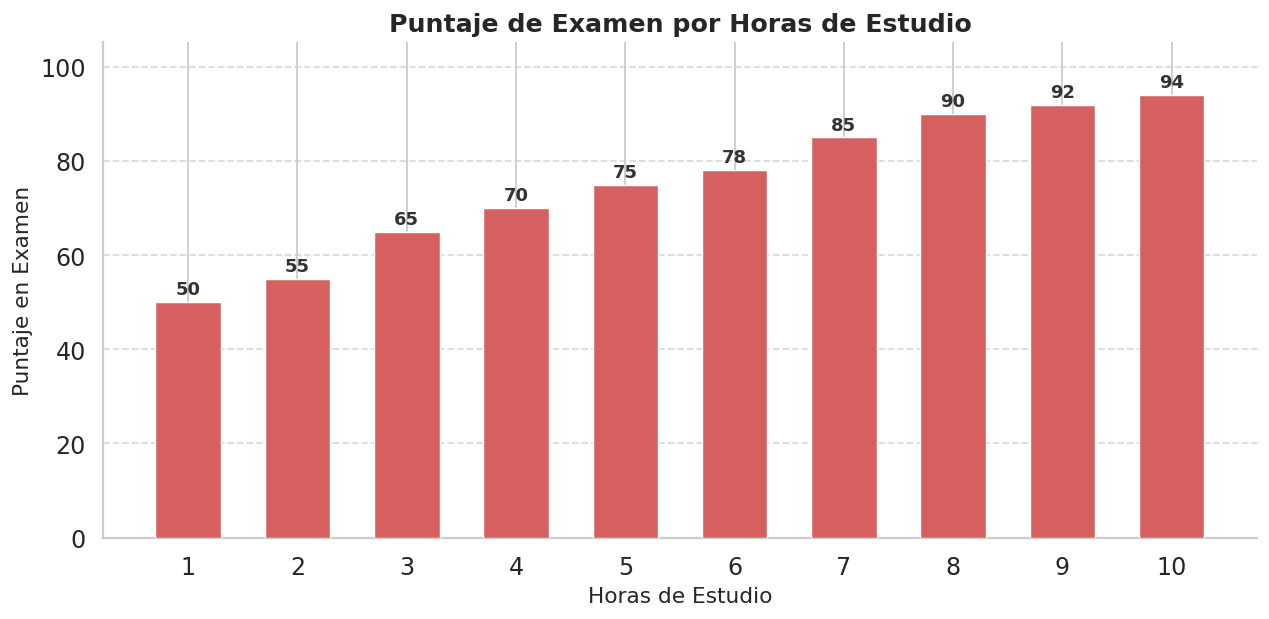

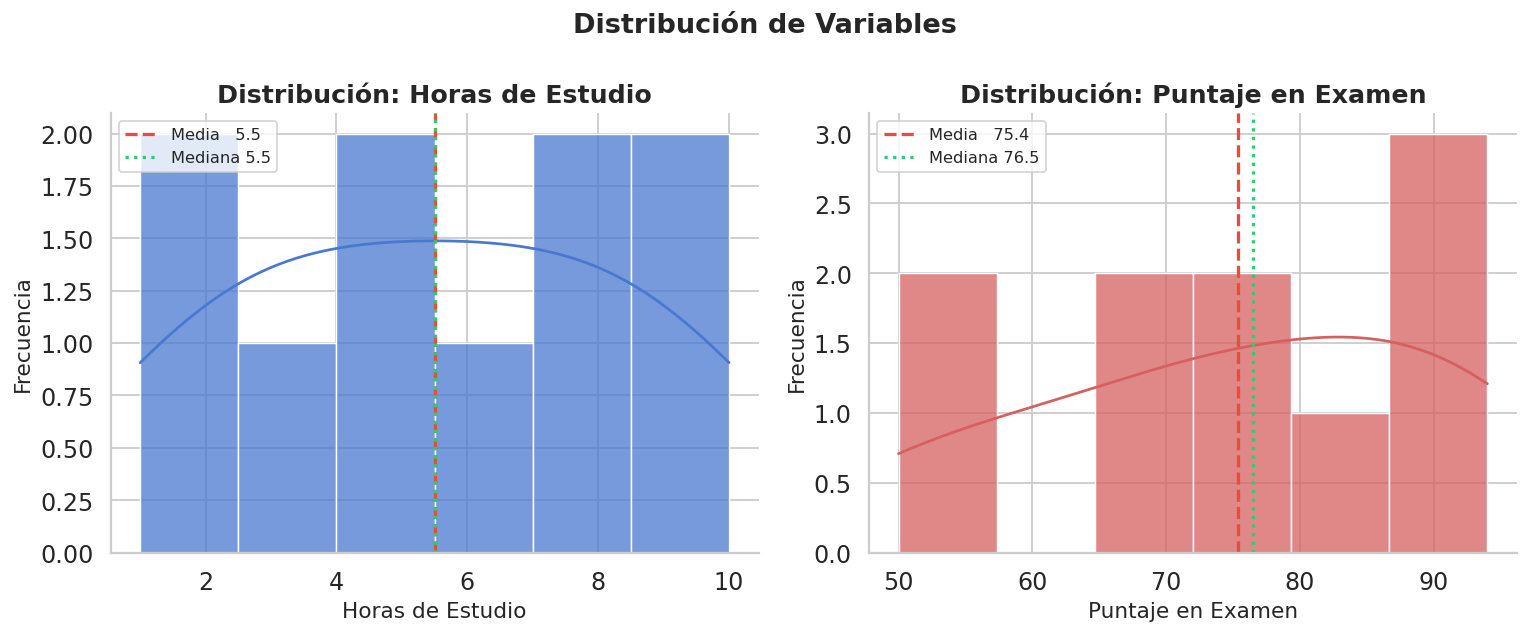

/tmp/ipykernel_7339/2979401273.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


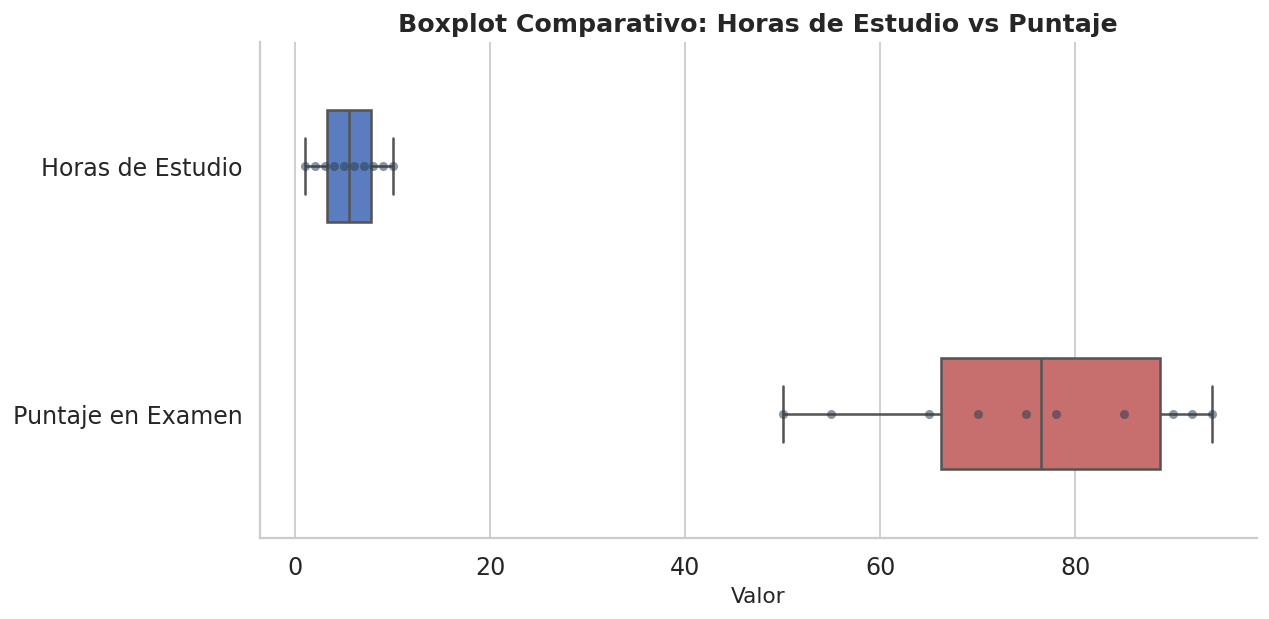

/tmp/ipykernel_7339/2979401273.py:191: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10)


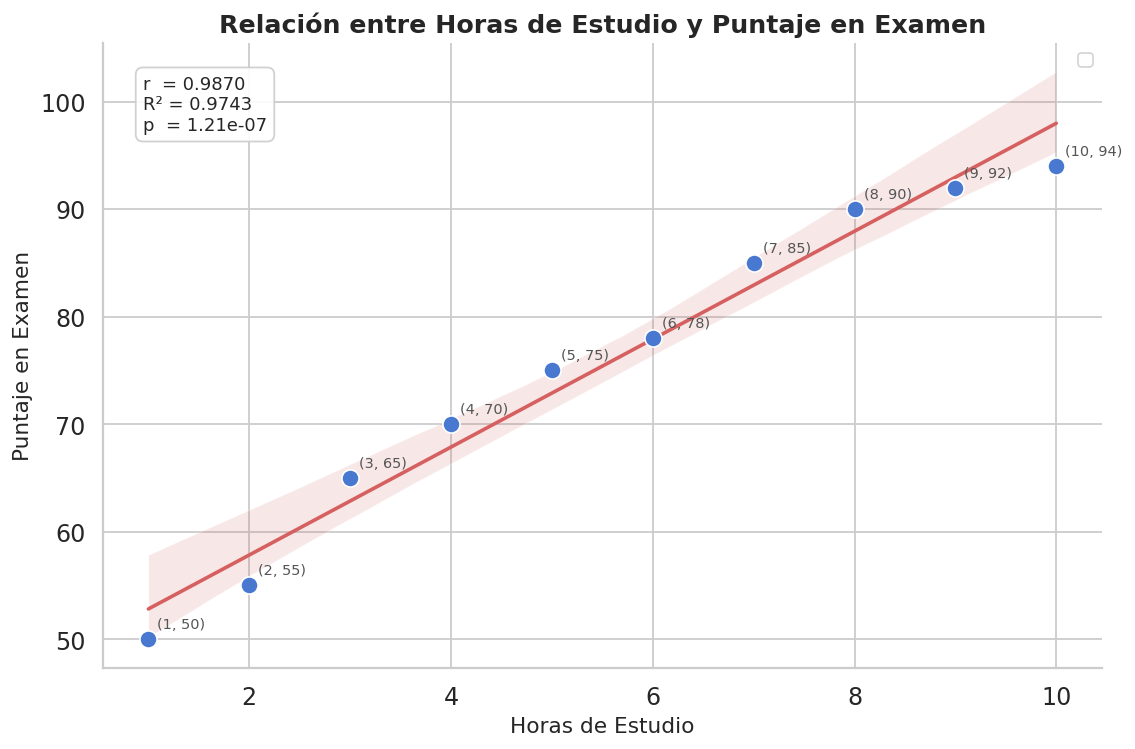

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ============================================================
# CONFIGURACIÓN VISUAL GLOBAL
# ============================================================
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PALETA   = sns.color_palette("muted")
COLOR_H  = PALETA[0]   # azul  → horas de estudio
COLOR_P  = PALETA[3]   # rojo  → puntaje examen

# ============================================================
# DATOS
# ============================================================
horas_estudio  = np.array([1,  2,  3,  4,  5,  6,  7,  8,  9, 10])
puntaje_examen = np.array([50, 55, 65, 70, 75, 78, 85, 90, 92, 94])

# ============================================================
# FUNCIONES DE VISUALIZACIÓN
# ============================================================

# ── 1. GRÁFICO DE BARRAS ────────────────────────────────────
def grafico_barras(horas: np.ndarray, puntajes: np.ndarray) -> None:
    """
    Barras verticales: eje X = horas de estudio,
    altura = puntaje obtenido. Anota el valor encima de cada barra.
    """
    fig, ax = plt.subplots(figsize=(10, 5))

    bars = ax.bar(
        horas, puntajes,
        color=COLOR_P, edgecolor="white",
        linewidth=0.8, width=0.6, zorder=3
    )

    # Anotación del valor sobre cada barra
    for bar, val in zip(bars, puntajes):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            str(val),
            ha="center", va="bottom",
            fontsize=10, fontweight="bold", color="#333333"
        )

    ax.set(
        title="Puntaje de Examen por Horas de Estudio",
        xlabel="Horas de Estudio",
        ylabel="Puntaje en Examen",
        xticks=horas,
        ylim=(0, max(puntajes) * 1.12)
    )
    ax.yaxis.grid(True, linestyle="--", alpha=0.7)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()


# ── 2. HISTOGRAMA ────────────────────────────────────────────
def histograma(horas: np.ndarray, puntajes: np.ndarray) -> None:
    """
    Dos histogramas con curva KDE superpuesta:
    distribución de horas de estudio y de puntajes.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Distribución de Variables", fontsize=15, fontweight="bold")

    datos = [(horas, COLOR_H, "Horas de Estudio",  "Frecuencia"),
             (puntajes, COLOR_P, "Puntaje en Examen", "Frecuencia")]

    for ax, (arr, color, xlabel, ylabel) in zip(axes, datos):
        sns.histplot(
            arr, bins=6, kde=True,
            color=color, alpha=0.75,
            edgecolor="white", linewidth=0.8,
            ax=ax
        )
        # Líneas de referencia: media y mediana
        ax.axvline(np.mean(arr),   color="#e74c3c", lw=1.8,
                   linestyle="--", label=f"Media   {np.mean(arr):.1f}")
        ax.axvline(np.median(arr), color="#2ecc71", lw=1.8,
                   linestyle=":",  label=f"Mediana {np.median(arr):.1f}")

        ax.set(title=f"Distribución: {xlabel}",
               xlabel=xlabel, ylabel=ylabel)
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()


# ── 3. BOXPLOT ───────────────────────────────────────────────
def boxplot(horas: np.ndarray, puntajes: np.ndarray) -> None:
    """
    Boxplot horizontal comparativo con puntos de datos superpuestos
    (stripplot) para visualizar la dispersión real.
    """
    import pandas as pd

    # Estructura larga para seaborn
    df = pd.DataFrame({
        "Valor"   : np.concatenate([horas, puntajes]),
        "Variable": (["Horas de Estudio"] * len(horas) +
                     ["Puntaje en Examen"] * len(puntajes))
    })

    fig, ax = plt.subplots(figsize=(10, 5))

    sns.boxplot(
        data=df, x="Valor", y="Variable",
        palette=[COLOR_H, COLOR_P],
        width=0.45, linewidth=1.4,
        flierprops=dict(marker="D", markersize=6,
                        markerfacecolor="#e74c3c", alpha=0.7),
        ax=ax
    )
    # Puntos individuales sobre las cajas
    sns.stripplot(
        data=df, x="Valor", y="Variable",
        color="#2c3e50", size=5, alpha=0.55, jitter=False, ax=ax
    )

    ax.set(
        title="Boxplot Comparativo: Horas de Estudio vs Puntaje",
        xlabel="Valor", ylabel=""
    )
    plt.tight_layout()
    plt.show()


# ── 4. SCATTER PLOT CON REGRESIÓN ────────────────────────────
def scatter_regresion(horas: np.ndarray, puntajes: np.ndarray) -> None:
    """
    Scatter plot con línea de regresión lineal, banda de confianza 95 %
    e indicadores estadísticos (r y R²).
    """
    # Cálculo de regresión
    slope, intercept, r, p_val, _ = stats.linregress(horas, puntajes)
    r2 = r ** 2

    fig, ax = plt.subplots(figsize=(9, 6))

    # Banda de confianza + línea de regresión via seaborn
    sns.regplot(
        x=horas, y=puntajes,
        scatter=False,
        line_kws={"color": COLOR_P, "linewidth": 2,
                  "label": f"Regresión: y = {slope:.2f}x + {intercept:.2f}"},
        ci=95,
        ax=ax
    )

    # Puntos con etiquetas
    ax.scatter(horas, puntajes, color=COLOR_H, s=90,
               edgecolors="white", linewidths=0.9, zorder=5)
    for x, y in zip(horas, puntajes):
        ax.annotate(
            f"({x}, {y})",
            xy=(x, y), xytext=(5, 6),
            textcoords="offset points",
            fontsize=8, color="#555555"
        )

    # Cuadro de estadísticas
    stats_txt = f"r  = {r:.4f}\nR² = {r2:.4f}\np  = {p_val:.2e}"
    ax.text(
        0.04, 0.95, stats_txt,
        transform=ax.transAxes,
        fontsize=10, verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.4",
                  facecolor="white", edgecolor="#cccccc", alpha=0.9)
    )

    ax.set(
        title="Relación entre Horas de Estudio y Puntaje en Examen",
        xlabel="Horas de Estudio",
        ylabel="Puntaje en Examen"
    )
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()


# ============================================================
# EJECUCIÓN PRINCIPAL
# ============================================================
if __name__ == "__main__":
    grafico_barras(horas_estudio, puntaje_examen)
    histograma(horas_estudio, puntaje_examen)
    boxplot(horas_estudio, puntaje_examen)
    scatter_regresion(horas_estudio, puntaje_examen)

4.Genera código en Python que calcule el coeficiente de correlación de Pearson entre:
horas_estudio = np.array([1,2,3,4,5,6,7,8,9,10])
puntaje_examen = np.array([50,55,65,70,75,78,85,90,92,94])

Requisitos:

Usar scipy.stats
Mostrar el valor del coeficiente y su interpretación (fuerte, moderada, débil)
Generar un heatmap de la matriz de correlación con seaborn
Código limpio y documentado


════════════════════════════════════════════════════
  🔗 CORRELACIÓN DE PEARSON
     Horas de Estudio  ←→  Puntaje en Examen
════════════════════════════════════════════════════
  Coef. de Pearson (r)             +0.987050
  Coef. de determinación (R²)        0.9743  (97.43%)
  p-valor                          1.21e-07
  ────────────────────────────────────────────────────
  📌 Fuerza        : MUY FUERTE
  📌 Dirección     : Correlación positiva
  📌 Significancia : p < 0.001 ✅ Altamente significativo
  ────────────────────────────────────────────────────
  💡 Interpretación:
     Existe una correlación muy fuerte y positiva
     entre Horas de Estudio y Puntaje en Examen.
     El R² = 0.9743 indica que el 97.4% de la
     variación en Puntaje en Examen es explicada por Horas de Estudio.
════════════════════════════════════════════════════



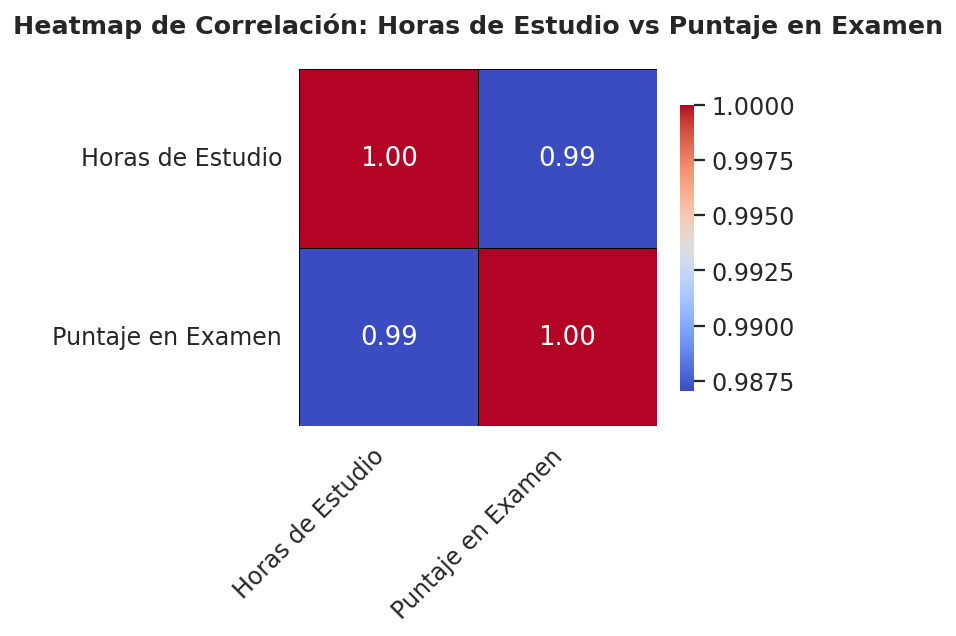

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ============================================================
# CONFIGURACIÓN VISUAL GLOBAL
# ============================================================
sns.set_theme(style="white", font_scale=1.2)
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
})

# ============================================================
# DATOS
# ============================================================
horas_estudio  = np.array([1,  2,  3,  4,  5,  6,  7,  8,  9, 10])
puntaje_examen = np.array([50, 55, 65, 70, 75, 78, 85, 90, 92, 94])

# ============================================================
# FUNCIÓN: INTERPRETAR EL COEFICIENTE DE PEARSON
# ============================================================
def interpretar_pearson(r: float) -> tuple[str, str]:
    """
    Devuelve (fuerza, dirección) según el valor de r.

    Escala estándar:
        |r| >= 0.90  → Muy fuerte
        |r| >= 0.70  → Fuerte
        |r| >= 0.50  → Moderada
        |r| >= 0.30  → Débil
        |r| <  0.30  → Muy débil / nula
    """
    abs_r     = abs(r)
    direccion = "positiva" if r > 0 else "negativa"

    if abs_r >= 0.90:
        fuerza = "MUY FUERTE"
    elif abs_r >= 0.70:
        fuerza = "FUERTE"
    elif abs_r >= 0.50:
        fuerza = "MODERADA"
    elif abs_r >= 0.30:
        fuerza = "DÉBIL"
    else:
        fuerza = "MUY DÉBIL / NULA"

    return fuerza, direccion


# ============================================================
# FUNCIÓN: CALCULAR Y REPORTAR PEARSON
# ============================================================
def calcular_pearson(x: np.ndarray, y: np.ndarray,
                     nombre_x: str, nombre_y: str) -> dict:
    """
    Calcula el coeficiente de Pearson entre x e y con scipy.stats
    e imprime un reporte estructurado.

    Retorna dict con r, p_value, r2 y la interpretación.
    """
    r, p_value = stats.pearsonr(x, y)
    r2         = r ** 2
    fuerza, direccion = interpretar_pearson(r)

    # Nivel de significancia
    if p_value < 0.001:
        sig = "p < 0.001 ✅ Altamente significativo"
    elif p_value < 0.01:
        sig = f"p = {p_value:.4f} ✅ Muy significativo"
    elif p_value < 0.05:
        sig = f"p = {p_value:.4f} ✅ Significativo"
    else:
        sig = f"p = {p_value:.4f} ❌ No significativo (α = 0.05)"

    # ── Reporte en consola ───────────────────────────────────
    sep  = "─" * 52
    sep2 = "═" * 52
    print(f"\n{sep2}")
    print(f"  🔗 CORRELACIÓN DE PEARSON")
    print(f"     {nombre_x}  ←→  {nombre_y}")
    print(f"{sep2}")
    print(f"  {'Coef. de Pearson (r)':<32} {r:>+.6f}")
    print(f"  {'Coef. de determinación (R²)':<32} {r2:>8.4f}  ({r2*100:.2f}%)")
    print(f"  {'p-valor':<32} {p_value:>8.2e}")
    print(f"  {sep}")
    print(f"  📌 Fuerza        : {fuerza}")
    print(f"  📌 Dirección     : Correlación {direccion}")
    print(f"  📌 Significancia : {sig}")
    print(f"  {sep}")
    print(f"  💡 Interpretación:")
    print(f"     Existe una correlación {fuerza.lower()} y {direccion}")
    print(f"     entre {nombre_x} y {nombre_y}.")
    print(f"     El R² = {r2:.4f} indica que el {r2*100:.1f}% de la")
    print(f"     variación en {nombre_y} es explicada por {nombre_x}.")
    print(f"{sep2}\n")

    return {"r": r, "p_value": p_value, "r2": r2,
            "fuerza": fuerza, "direccion": direccion}

# ============================================================
# FUNCIÓN: VISUALIZAR HEATMAP DE CORRELACIÓN
# ============================================================
def heatmap_correlacion(data: dict, titulo: str) -> None:
    """
    Genera un heatmap de la matriz de correlación.
    """
    # Asegurarse de que el diccionario tiene la estructura esperada
    if "r" not in data or "r2" not in data:
        print("Error: El diccionario de datos debe contener 'r' y 'r2'.")
        return

    # Crear una matriz de correlación 2x2 para las dos variables
    # La correlación de una variable consigo misma es 1
    corr_matrix = np.array([
        [1, data["r"]],
        [data["r"], 1]
    ])

    # Etiquetas para el heatmap
    labels = ["Horas de Estudio", "Puntaje en Examen"]

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        corr_matrix,
        annot=True, # Mostrar los valores en las celdas
        fmt=".2f",  # Formato de los valores a dos decimales
        cmap="coolwarm", # Mapa de color divergente
        linewidths=.5, # Líneas entre celdas
        linecolor="black",
        cbar_kws={"shrink": .8},
        square=True, # Asegura celdas cuadradas
        xticklabels=labels,
        yticklabels=labels,
    )
    plt.title(titulo, pad=20)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


# ============================================================
# EJECUCIÓN PRINCIPAL
# ============================================================
if __name__ == "__main__":
    # Calcular Pearson y obtener los resultados
    resultados_pearson = calcular_pearson(
        horas_estudio, puntaje_examen,
        "Horas de Estudio", "Puntaje en Examen"
    )

    # Generar el heatmap de correlación
    heatmap_correlacion(
        resultados_pearson,
        "Heatmap de Correlación: Horas de Estudio vs Puntaje en Examen"
    )
